# 03 · Navigating: Extended Kalman Filter vs particle filter

An inertial navigation system (INS) accumulates error and slowly **drifts**. Magnetic navigation corrects that drift using the map: when the filter's assumed position sits on the wrong part of the map, the mismatch between predicted and measured field tells it which way to nudge the estimate.

We build the whole chain from `magnavlab` primitives and run two filters:
- **EKF** (Extended Kalman Filter) — fast; represents belief as a single Gaussian;
- **PF** (particle filter) — a cloud of candidate positions; more robust to map ambiguity.

Each step is spelled out below.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Load the flight, map and a survey line (decimated 10 → 2 Hz)

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.calibration import BuiltinTL
from magnavlab.ins import real_ins
from magnavlab.filters import EKFNav, ParticleFilterNav
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]
dt = nav.dt * 5
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
alt = nav.get('alt')[idx]; tt = nav.get('tt')[idx]
print(f'{idx.size} samples @ {1/dt:.0f} Hz')

7569 samples @ 2 Hz


## 2. Compensate the cabin magnetometer (Tolles-Lawson)
We calibrate on flight 1002's dedicated calibration manoeuvres, apply the coefficients to the noisy `mag_4_uc` on our flight, and subtract the day's (diurnal) field variation.

In [3]:
cal_flight = load_flight('data/Flt1002_train.h5')
cal_idx = np.concatenate([segment_indices(cal_flight, a, b) for a, b in data.CAL_SEGMENTS['Flt1002']])
calibrator = BuiltinTL().fit(cal_flight.flux(cal_idx), cal_flight.get('mag_4_uc')[cal_idx], cal_flight.dt)
measurement = calibrator.compensate(nav.flux(idx), nav.get('mag_4_uc')[idx], dt) - nav.get('diurnal')[idx]

## 3. Line the measurement up with the map
Remove a constant offset, then estimate the measurement noise `sigma_meas` from the leftover scatter — the filter needs to know how far to trust each reading.

In [4]:
map_along = mag_map.value(lat, lon); valid = np.isfinite(map_along)
measurement = measurement - np.median(measurement[valid] - map_along[valid])
resid = (measurement - map_along)[valid]
sigma_meas = max(1.4826 * np.median(np.abs(resid - np.median(resid))), 5.0)
print(f'corr(measurement, map)={np.corrcoef(measurement[valid], map_along[valid])[0,1]:.3f}, sigma_meas={sigma_meas:.1f} nT')

corr(measurement, map)=0.966, sigma_meas=84.7 nT


## 4. Use the real onboard INS
Instead of a synthetic drift we take the aircraft's **recorded onboard INS** solution (`ins_lat`, `ins_lon`, `ins_vn`, ...) and anchor it to truth at the start of the line (so the position error begins at 0), giving the map a real error to correct.

In [5]:
ins = real_ins(nav, idx, anchor=(lat[0], lon[0]))          # real onboard INS, anchored at start
ins_lat, ins_lon = ins['lat'], ins['lon']
problem = NavProblem(dt=dt, map=mag_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=measurement)

## 5. Run the two filters
Both take the same `NavProblem` and return an estimated track. **DRMS** is the RMS horizontal error in metres; **CEP50 / CEP95** are the 50th / 95th-percentile error radii.

In [6]:
ekf = EKFNav(sigma_meas=sigma_meas).run(problem)
pf  = ParticleFilterNav(sigma_meas=sigma_meas).run(problem)
ins_result = NavResult(lat=ins_lat, lon=ins_lon)
for name, result in [('INS', ins_result), ('EKF', ekf), ('PF', pf)]:
    m = summary(result, lat, lon)
    print(f"{name:4s} DRMS={m['drms']:7.1f} m  CEP50={m['cep50']:6.1f}  CEP95={m['cep95']:6.1f}")

INS  DRMS=  114.5 m  CEP50= 111.2  CEP95= 164.4
EKF  DRMS=  104.6 m  CEP50=  92.0  CEP95= 168.7
PF   DRMS=  131.5 m  CEP50= 120.3  CEP95= 207.1


## 6. Where the estimate sits on the map
Background = the anomaly field; **black = true path**; coloured lines = each filter's estimate, zoomed in tight. The estimates hug the truth. (The un-aided INS is left out on purpose — it would drift kilometres off and flatten the view.)

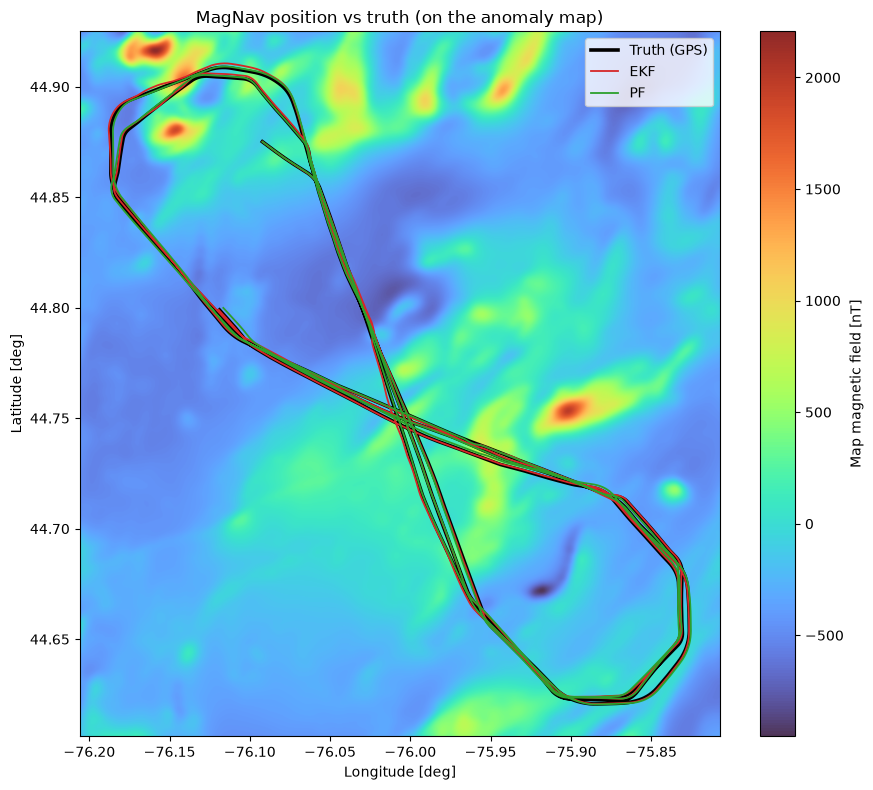

In [7]:
viz.plot_tracks_vs_truth(mag_map, lat, lon, {'EKF': (ekf, 'tab:red'), 'PF': (pf, 'tab:green')});

## 7. Error over time
Horizontal position error in metres versus time. The **INS** curve climbs as it drifts; the **EKF** and **PF** stay low and flat — the map is holding the solution in place. The legend reports each track's DRMS.

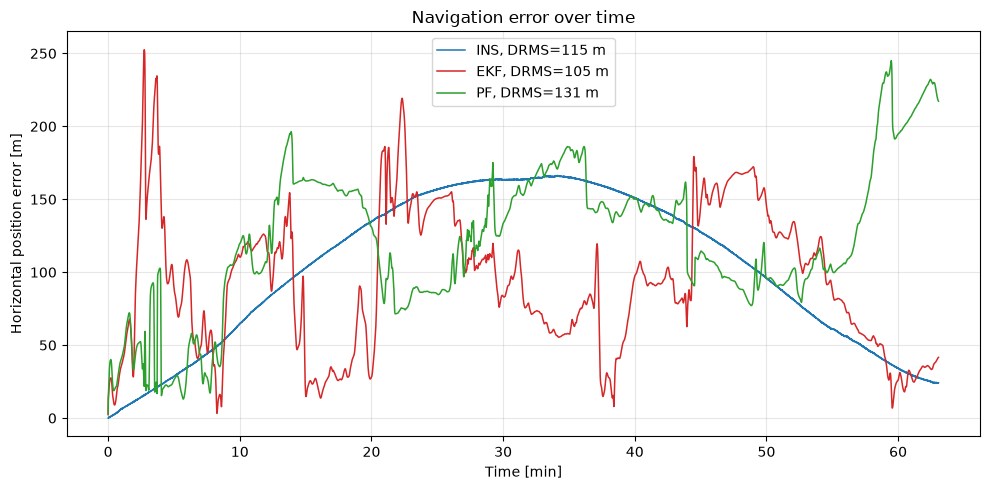

In [8]:
viz.plot_error_time(tt, lat, lon,
    {'INS': (ins_result,'tab:blue'), 'EKF': (ekf,'tab:red'), 'PF': (pf,'tab:green')});